In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
import matplotlib.pyplot as plt
from GAKELM import GeneticELMRegressor


In [2]:
np.set_printoptions(suppress=True)

In [3]:
sc1 = MinMaxScaler(feature_range = (0, 1)) #use to normalize training data
sc2 = MinMaxScaler(feature_range = (0, 1)) #use to normalize label data

In [7]:
#interpolate function to deal with missing values and outliers
def interpolate_nans(X):
    """Overwrite NaNs with column value interpolations."""
    for j in range(X.shape[1]):
        mask_j = np.isnan(X[:,j])
        X[mask_j,j] = np.interp(np.flatnonzero(mask_j), np.flatnonzero(~mask_j), X[~mask_j,j])
    return X

In [8]:
#loading and displaying dataset values
dataset = pd.read_csv("Dataset/Dataset.csv")
dataset.fillna(0, inplace = True)
dataset

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,0.0,0.0,0.92,18.22,17.15,0.0,0.92,27.64,133.36,0.00,0.02,0.00,0.0,0
1,Ahmedabad,2015-01-02,0.0,0.0,0.97,15.69,16.46,0.0,0.97,24.55,34.06,3.68,5.50,3.77,0.0,0
2,Ahmedabad,2015-01-03,0.0,0.0,17.40,19.30,29.70,0.0,17.40,29.07,30.70,6.80,16.40,2.25,0.0,0
3,Ahmedabad,2015-01-04,0.0,0.0,1.70,18.48,17.97,0.0,1.70,18.59,36.08,4.43,10.14,1.00,0.0,0
4,Ahmedabad,2015-01-05,0.0,0.0,22.10,21.42,37.76,0.0,22.10,39.33,39.31,7.01,18.89,2.78,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497,Ahmedabad,2016-05-12,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0
498,Ahmedabad,2016-05-13,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0
499,Ahmedabad,2016-05-14,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0
500,Ahmedabad,2016-05-15,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0


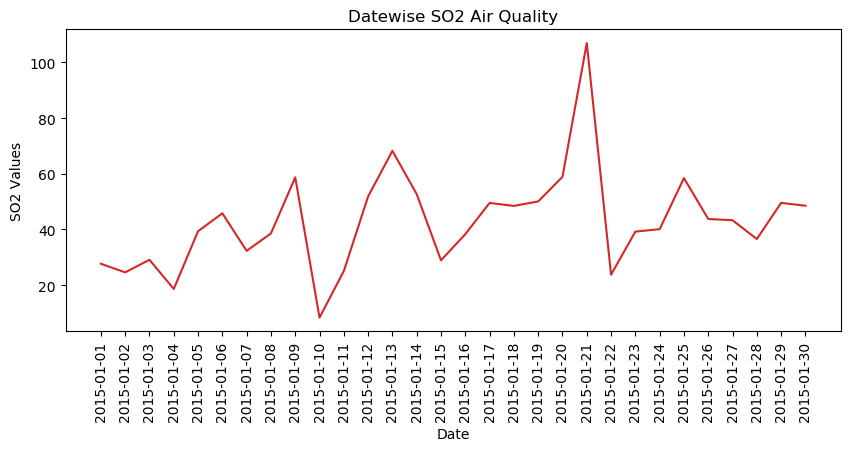

In [9]:
plt.figure(figsize=(10,4), dpi=100)
plt.plot(dataset.Date[0:30], dataset.SO2[0:30], color='tab:red')
plt.gca().set(title="Datewise SO2 Air Quality", xlabel='Date', ylabel="SO2 Values")
plt.xticks(rotation=90)
plt.show()

In [10]:
#dataset preprocessing such as normalization and extracting train and test data from dataset
#extracting X features and Y label from dataset
Y = dataset.values[:,2:3]
dataset.drop(['City'], axis = 1,inplace=True) #removing irrelevant columns
dataset.drop(['Date'], axis = 1,inplace=True)
dataset.drop(['PM2.5'], axis = 1,inplace=True)
dataset.drop(['AQI_Bucket'], axis = 1,inplace=True)
dataset = dataset.values
X = dataset[:,3:dataset.shape[1]-1]

#outlier and missing values removal using interpolation
X = interpolate_nans(X)

X = sc1.fit_transform(X)
Y = sc2.fit_transform(Y)
print("Normalized Training Features")
print(X)

Normalized Training Features
[[0.08532338 0.         0.00633086 ... 0.         0.00012222 0.        ]
 [0.08189055 0.         0.00667492 ... 0.0501499  0.03361036 0.10472222]
 [0.14776119 0.         0.11973576 ... 0.0926683  0.10022    0.0625    ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2)
print("Total records found in dataset  = "+str(X.shape[0]))
print("Total features found in dataset = "+str(X.shape[1]))
print("80% dataset for training : "+str(X_train.shape[0]))
print("20% dataset for testing  : "+str(X_test.shape[0]))

Total records found in dataset  = 502
Total features found in dataset = 8
80% dataset for training : 401
20% dataset for testing  : 101


In [12]:
mse = []
rmse = []

In [ ]:
# Calculate MSE and RMSE
def calculateMetrics(algorithm, predict, test_labels):
    predict = sc2.inverse_transform(np.asarray(predict).reshape(-1, 1)).ravel()
    test_label = sc2.inverse_transform(np.asarray(test_labels).reshape(-1, 1)).ravel()
    mse_value = mean_squared_error(test_label, predict)
    rmse_value = np.sqrt(mse_value)
    mse.append(mse_value)
    rmse.append(rmse_value)
    print(f'{algorithm} MSE  : {mse_value:.6f}')
    print(f'{algorithm} RMSE : {rmse_value:.6f}')


Existing SVR MSE  : 9.675495327734815
Existing SVR RMSE : 3.110545824728325


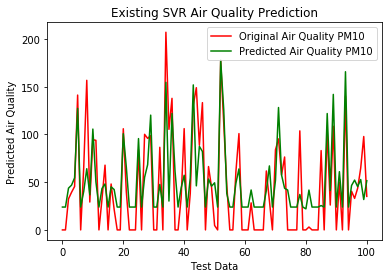

In [14]:
#now train existing SVM algorithm
svm_cls = svm.SVR()
svm_cls.fit(X_train, y_train.ravel())
predict = svm_cls.predict(X_test)
predict = predict.reshape(-1, 1)
calculateMetrics("Existing SVR", predict, y_test)

Propose GA-KELM MSE  : 6.981265443864735
Propose GA-KELM RMSE : 2.6422084406542825


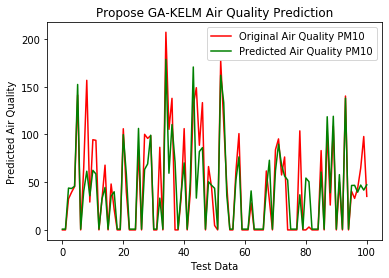

In [15]:
#creating object of genetic EML object by calling class
elm = GeneticELMRegressor()
elm.fit(X_train, y_train)#now train genetic elm on training data
predict = elm.predict(X_test) #perform prediction on test data
calculateMetrics("Propose GA-KELM", predict, y_test)#calculate metrics

In [ ]:
results = pd.DataFrame({
    'Algorithm': ['SVR', 'GA-KELM'],
    'MSE': mse,
    'RMSE': rmse
})
results.set_index('Algorithm')[['MSE', 'RMSE']].plot(kind='bar', figsize=(8, 5))
plt.title('SVR vs GA-KELM Performance')
plt.ylabel('Error')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
results
